Running inference on: mps
Loading checkpoint from: /Users/acit/Documents/MyWork/Stabel Diffusion/data/v1-5-pruned-emaonly.ckpt


100%|██████████| 10/10 [11:47<00:00, 70.78s/it]


Image saved to: /Users/acit/Documents/MyWork/Stabel Diffusion/outputs/demo_output_20260825_044553.png


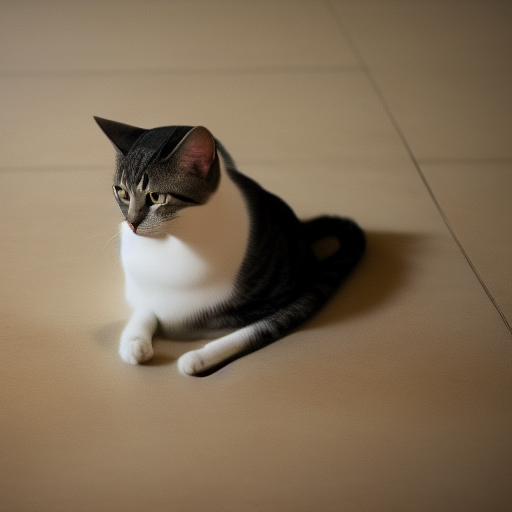

In [3]:
from datetime import datetime
from pathlib import Path

import torch
from IPython.display import display
from PIL import Image
from transformers import CLIPTokenizer

import model_loader
import pipeline


# =========================
# PATHS
# =========================

SD_DIR = Path.cwd()
if SD_DIR.name != "sd" and (SD_DIR / "sd").is_dir():
    SD_DIR = SD_DIR / "sd"
ROOT_DIR = SD_DIR.parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

VOCAB_FILE = DATA_DIR / "vocab.json"
MERGES_FILE = DATA_DIR / "merges.txt"
MODEL_FILE = DATA_DIR / "v1-5-pruned-emaonly.ckpt"


# =========================
# DEVICE
# =========================

if torch.backends.mps.is_available():
    RUN_DEVICE = torch.device("mps")
else:
    RUN_DEVICE = torch.device("cpu")

# Load models initially on CPU.
# Pipeline will move each model to MPS only when needed.
IDLE_DEVICE = torch.device("cpu")

print(f"Running inference on: {RUN_DEVICE}")
print(f"Loading checkpoint from: {MODEL_FILE}")


# =========================
# TOKENIZER AND MODELS
# =========================

tokenizer = CLIPTokenizer(
    vocab=str(VOCAB_FILE),
    merges=str(MERGES_FILE),
)

models = model_loader.preload_models_from_standard_weights(
    str(MODEL_FILE),
    IDLE_DEVICE,
)


# =========================
# LIGHTWEIGHT LIVE DEMO
# =========================

# Reduce resolution for MacBook Air M3 8 GB.
pipeline.WIDTH = 512
pipeline.HEIGHT = 512
pipeline.LATENTS_WIDTH = pipeline.WIDTH // 8
pipeline.LATENTS_HEIGHT = pipeline.HEIGHT // 8

prompt = (
    "A cat stretching on the floor, highly detailed, "
    "cinematic lighting"
)

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt="",
    input_image=None,
    strength=0.9,

    # Disable CFG for lower memory usage during live demo.
    do_cfg=True,
    cfg_scale=7.5,

    sampler_name="ddpm",
    n_inference_steps=10,
    seed=42,

    models=models,
    device=RUN_DEVICE,
    idle_device=IDLE_DEVICE,
    tokenizer=tokenizer,
)


# =========================
# SAVE RESULT
# =========================

result = Image.fromarray(output_image)

output_path = OUTPUT_DIR / f"demo_output_{datetime.now():%Y%m%d_%H%M%S}.png"
result.save(output_path)

print(f"Image saved to: {output_path}")

display(result)